Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

Loading dataset

In [2]:
PROJECT_ROOT = Path.cwd().parent
METADATA_PATH = PROJECT_ROOT / "data" / "raw" / "PlantSeg" / "Metadata.csv"

df = pd.read_csv(METADATA_PATH)

EDA

In [3]:
df.head()

,Name,Index,Plant,Disease,Resolution,Label file,Mask ratio,URL,License,Split
0,apple_black_rot_1.jpg,0,Apple,apple black rot,640x480,apple_black_rot_1.png,0.040439,https://baijiahao.baidu.com/s?id=1592172448991...,CC-BY-NC,Training
1,apple_black_rot_11.jpg,0,Apple,apple black rot,1080x755,apple_black_rot_11.png,0.057550,http://dy.163.com/v2/article/detail/EJ3OGOG605...,CC-BY-NC,Training
2,apple_black_rot_12.jpg,0,Apple,apple black rot,1280x719,apple_black_rot_12.png,0.024791,http://baijiahao.baidu.com/s?id=16205160930871...,CC-BY-NC,Training
3,apple_black_rot_15.jpg,0,Apple,apple black rot,600x355,apple_black_rot_15.png,0.236169,http://www.360doc.cn/article/4310958_180040780...,CC-BY-NC,Training
4,apple_black_rot_156.jpg,0,Apple,apple black rot,219x294,apple_black_rot_156.png,0.054344,http://baijiahao.baidu.com/s?id=16352401074244...,CC-BY-NC,Training


In [4]:
#Dataset Dimentions
print(f"Shape : {df.shape}")
print(f"Columns : {df.shape[1]}") #can use df.columns to get the column names
print(f"Rows : {df.shape[0]}") #can use df.index to get the row names

Shape : (7774, 10)
Columns : 10
Rows : 7774


In [5]:
df.dtypes

Name              str
Index           int64
Plant             str
Disease           str
Resolution        str
Label file        str
Mask ratio    float64
URL               str
License           str
Split             str
dtype: object

In [6]:
#missing values
df.isnull().sum()

Name          0
Index         0
Plant         0
Disease       0
Resolution    0
Label file    0
Mask ratio    0
URL           0
License       0
Split         0
dtype: int64

Understand categorical variables

In [7]:
print("Unique plants:", df["Plant"].nunique())
print("Unique diseases:", df["Disease"].nunique())
print("Unique splits:", df["Split"].nunique())

Unique plants: 34
Unique diseases: 115
Unique splits: 3


In [8]:
df["Split"].value_counts()

Split
Training      5367
Test          1561
Validation     846
Name: count, dtype: int64

**Investigate class imbalance**
How balanced or imbalanced are the disease classes?

In [9]:
disease_counts = df["Disease"].value_counts()

print("Total diseases ", len(disease_counts))
print("Disease with highest count: ", disease_counts.max())
print("Disease with lowest count: ", disease_counts.min())
print("Average disease count : ", round(disease_counts.mean(),2))

Total diseases  115
Disease with highest count:  323
Disease with lowest count:  3
Average disease count :  67.6


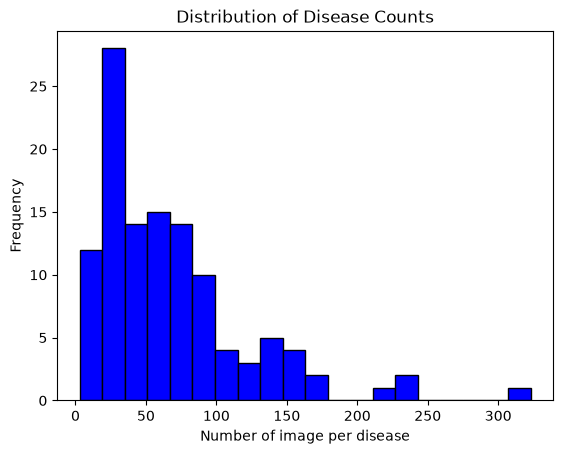

In [10]:
#plt.figure(figsize=(12,6))
plt.hist(disease_counts,bins=20, color='blue', edgecolor='black')
plt.title("Distribution of Disease Counts")
plt.xlabel("Number of image per disease")
plt.ylabel("Frequency")
plt.show()


Which plants are represented? Does the dataset contain a balanced number of images across different plants


In [11]:
plant_counts = df["Plant"].value_counts()

print("Total plants",len(plant_counts))
print("Top 10 plants", plant_counts.head(10))
print("Bottom 10 plants", plant_counts.tail(10))
print("Average plant count : ", round(plant_counts.mean(),2))
print("Plant with highest count :", plant_counts.max())
print("Plant with lowest count : ",plant_counts.min())

Total plants 34
Top 10 plants Plant
Wheat       1166
Tomato       667
Soybean      500
Corn         419
Citrus       416
Apple        402
Grape        400
Cucumber     383
Banana       354
Peach        287
Name: count, dtype: int64
Bottom 10 plants Plant
Broccoli       91
Cherry         91
Ginger         81
Raspberry      77
Lettuce        76
Maple          58
Cauliflower    53
Strawberry     49
Basil          41
Celery         40
Name: count, dtype: int64
Average plant count :  228.65
Plant with highest count : 1166
Plant with lowest count :  40


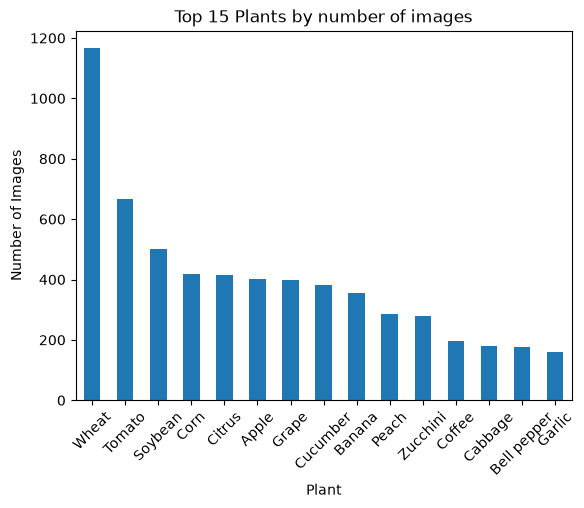

In [12]:
plant_counts.head(15).plot(kind='bar')
plt.title("Top 15 Plants by number of images")
plt.xlabel("Plant")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

In [13]:
plant_disease = pd.crosstab(df["Plant"], df["Disease"])

plant_disease.shape

(34, 115)

In [14]:
diseases_per_plant = df.groupby("Plant")["Disease"].nunique()

print(diseases_per_plant.sort_values(ascending=False).head(15))

Plant
Wheat          8
Tomato         7
Soybean        6
Banana         6
Plum           5
Blueberry      5
Peach          5
Apple          4
Corn           4
Bell pepper    4
Raspberry      4
Grape          4
Tobacco        4
Coffee         4
Zucchini       4
Name: Disease, dtype: int64


inspect the relationship

Rather than immediately making a giant 34 × 115 heatmap—which would be unreadable - we'll first ask a useful question:For each plant, which diseases actually occur in it?

In [15]:
plant_disease_list = (
    df.groupby("Plant")["Disease"]
      .unique()
)

for plant, diseases in plant_disease_list.items():
    print(f"\n{plant}:")
    print(", ".join(diseases))

#i notice that almost all the diseases are plant specific like the apple has diseases thet attack apple only and wheat has diseases that attact wheat only etc. But I won't say "every disease is exclusive to one plant" yet.


Apple:
apple black rot, apple mosaic virus, apple rust, apple scab

Banana:
banana anthracnose, banana black leaf streak, banana bunchy top, banana cigar end rot, banana cordana leaf spot, banana panama disease

Basil:
basil downy mildew

Bean:
bean halo blight, bean mosaic virus, bean rust

Bell pepper:
bell pepper bacterial spot, bell pepper blossom end rot, bell pepper frogeye leaf spot, bell pepper powdery mildew

Blueberry:
blueberry anthracnose, blueberry botrytis blight, blueberry mummy berry, blueberry rust, blueberry scorch

Broccoli:
broccoli alternaria leaf spot, broccoli downy mildew, broccoli ring spot

Cabbage:
cabbage alternaria leaf spot, cabbage black rot, cabbage downy mildew

Carrot:
carrot alternaria leaf blight, carrot cavity spot, carrot cercospora leaf blight

Cauliflower:
cauliflower alternaria leaf spot, cauliflower bacterial soft rot

Celery:
celery anthracnose, celery early blight

Cherry:
cherry leaf spot, cherry powdery mildew

Citrus:
citrus canker, citru

In [16]:
df.groupby("Plant")["Disease"].count().reset_index()

,Plant,Disease
0,Apple,402
1,Banana,354
2,Basil,41
3,Bean,144
4,Bell pepper,176
5,Blueberry,142
6,Broccoli,91
7,Cabbage,181
8,Carrot,105
9,Cauliflower,53


In [17]:
df.groupby("Plant")["Disease"].value_counts()

Plant     Disease                     
Apple     apple scab                      168
          apple rust                       98
          apple mosaic virus               73
          apple black rot                  63
Banana    banana black leaf streak        114
                                         ... 
Wheat     wheat leaf rust                  75
Zucchini  zucchini powdery mildew         133
          zucchini bacterial wilt          57
          zucchini yellow mosaic virus     56
          zucchini downy mildew            33
Name: count, Length: 115, dtype: int64

In [18]:
#Our current analysis shows strong plant-specificity, but we haven't formally verified that every disease belongs to exactly one plant.
#lets test this :

disease_plant_counts = df.groupby("Disease")["Plant"].nunique()

print("Diseases occurring on exactly one plant:",
      (disease_plant_counts == 1).sum())

print("Diseases occurring on multiple plants:",
      (disease_plant_counts > 1).sum())

print("\nDiseases occurring on multiple plants:")
print(disease_plant_counts[disease_plant_counts > 1])

Diseases occurring on exactly one plant: 115
Diseases occurring on multiple plants: 0

Diseases occurring on multiple plants:
Series([], Name: Plant, dtype: int64)


Lets visualise : How many images does each disease actually have?

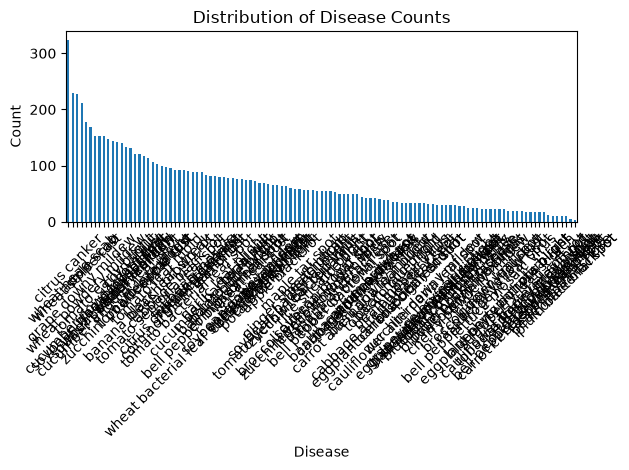

In [19]:
disease_counts.plot(kind="bar")
plt.title("Distribution of Disease Counts")
plt.xlabel("Disease")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout() # it's used to automatically adjust subplot parameters so that your plots fit cleanly inside the figure area
plt.show()

In [20]:
#Let's properly analyze the distribution

disease_counts.describe()

count    115.000000
mean      67.600000
std       53.662656
min        3.000000
25%       29.000000
50%       55.000000
75%       89.000000
max      323.000000
Name: count, dtype: float64

__Image Characteristics Analysis__

In [21]:
from PIL import Image   #Python Imaging Library module adds extensive image processing capabilities to Python. discontinued in 2011
from pathlib import Path  # offers an object-oriented way to handle and manage filesystem paths across different operating systems
from collections import Counter  #provides high-performance, specialized container datatypes that serve as alternatives to the general-purpose built-in containers

image_dir = Path("../data/raw/PlantSeg/images")

image_sizes = []

#rglob() recursively search a directory and all of its subdirectories for files and folders that match a specific pattern
for image_path in image_dir.rglob("*.jpg"):
    try:
        with Image.open(image_path) as img:
            image_sizes.append(img.size)  #img.size returns a tuple (width, height)
    except Exception:
        pass  #ignore any errors that occur while opening the image

print("Total images checked:", len(image_sizes))
print("Unique image sizes:", len(set(image_sizes)))

print("\nMost common image sizes:")
for size, count in Counter(image_sizes).most_common(15):
    print(size, "→", count)

Total images checked: 7774
Unique image sizes: 3895

Most common image sizes:
(640, 480) → 149
(1024, 768) → 128
(600, 380) → 107
(1200, 900) → 79
(600, 400) → 73
(800, 600) → 72
(1200, 1600) → 61
(300, 225) → 60
(1280, 720) → 59
(600, 450) → 58
(768, 1024) → 56
(640, 853) → 53
(500, 375) → 49
(1200, 800) → 49
(1600, 1200) → 48


In [22]:
# Calculate aspect ratios

aspect_ratios = [width / height for width, height in image_sizes]

print("Minimum aspect ratio:", round(min(aspect_ratios), 2))
print("Maximum aspect ratio:", round(max(aspect_ratios), 2))

print("\nMost common aspect ratios:")

rounded_ratios = [round(ratio, 2) for ratio in aspect_ratios]

for ratio, count in Counter(rounded_ratios).most_common(15):
    print(ratio, "→", count)

Minimum aspect ratio: 0.34
Maximum aspect ratio: 4.5

Most common aspect ratios:
1.33 → 1445
1.5 → 843
0.75 → 765
1.0 → 313
1.78 → 290
0.67 → 172
1.51 → 154
1.58 → 151
1.34 → 128
1.49 → 112
1.55 → 96
0.56 → 90
1.52 → 78
1.48 → 69
1.61 → 69


In [23]:
# Find images with extreme aspect ratios

extreme_images = []

for image_path in image_dir.rglob("*.jpg"):
    try:
        with Image.open(image_path) as img:
            width, height = img.size
            ratio = width / height

            if ratio < 0.5 or ratio > 3:
                extreme_images.append(
                    (image_path.name, width, height, round(ratio, 2))
                )

    except Exception:
        pass

print("Number of extreme-ratio images:", len(extreme_images))

print("\nExamples:")
for item in extreme_images[:20]:
    print(item)

Number of extreme-ratio images: 36

Examples:
('banana_cigar_end_rot_Google_0101.jpg', 800, 1777, 0.45)
('blueberry_anthracnose_Bing_0145.jpg', 500, 114, 4.39)
('corn_rust_google_0071.jpg', 1440, 320, 4.5)
('rice_blast_google_0062.jpg', 242, 541, 0.45)
('apple_rust_78.jpg', 640, 1387, 0.46)
('apple_scab_62.jpg', 650, 1409, 0.46)
('apple_scab_65.jpg', 640, 1387, 0.46)
('banana_bunchy_top_Google_0109.jpg', 3600, 800, 4.5)
('citrus_canker_46.jpg', 640, 1422, 0.45)
('citrus_canker_google_0197.jpg', 1235, 2480, 0.5)
('corn_northern_leaf_blight_7.jpg', 478, 959, 0.5)
('corn_rust_google_0049.jpg', 2338, 597, 3.92)
('cucumber_powdery_mildew_51.jpg', 640, 1385, 0.46)
('garlic_rust_103.jpg', 159, 370, 0.43)
('grape_downy_mildew_87.jpg', 495, 1023, 0.48)
('potato_early_blight_google_0119.jpg', 750, 230, 3.26)
('rice_blast_17.jpg', 1056, 2280, 0.46)
('soybean_frog_eye_leaf_spot_Bing_0118.jpg', 583, 1200, 0.49)
('strawberry_anthracnose_10.jpg', 650, 1449, 0.45)
('tobacco_brown_spot_Bing_0015.jpg', 

What do these extreme images actually look like?

In [ ]:
#path issue resolution

from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

print("Current working directory:")
print(Path.cwd())

print("\nProject root:")
print(PROJECT_ROOT)

Current working directory:
c:\Users\Dell\Documents\Projects\AgriSense\notebooks

Project root:
c:\Users\Dell\Documents\Projects\AgriSense


In [27]:
image_dir = PROJECT_ROOT / "data" / "raw" / "PlantSeg" / "images"

print(image_dir)
print("Exists:", image_dir.exists())

c:\Users\Dell\Documents\Projects\AgriSense\data\raw\PlantSeg\images
Exists: True


In [31]:
#creating a lookup for actual file names and therir actual paths

image_lookup = {}

for image_path in image_dir.rglob("*.jpg"):
    image_lookup[image_path.name]=image_path

print("Images Found : ",len(image_lookup))



Images Found :  7774


In [36]:
file_name = extreme_images[0][0]  # Get the first extreme image's file name

print("File name:", file_name)
print("File path", image_lookup[file_name])

File name: banana_cigar_end_rot_Google_0101.jpg
File path c:\Users\Dell\Documents\Projects\AgriSense\data\raw\PlantSeg\images\test\banana_cigar_end_rot_Google_0101.jpg


Visual inspection

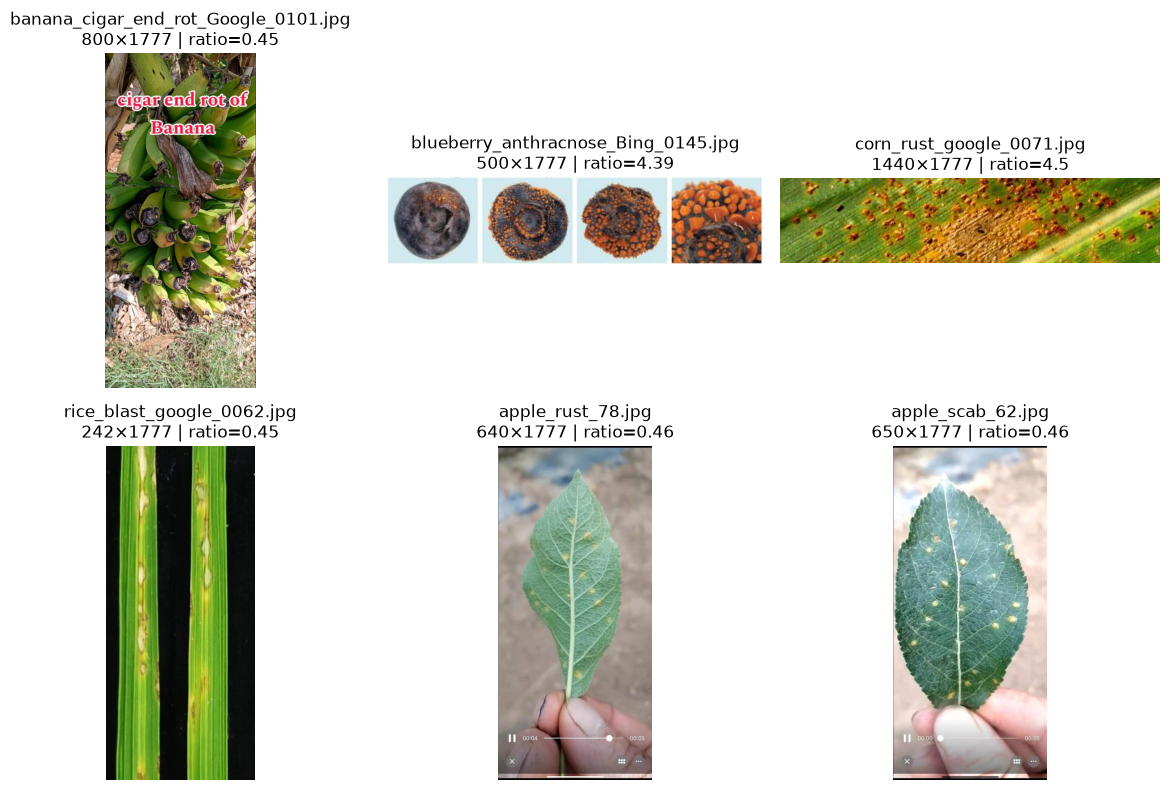

In [37]:
fig, axes = plt.subplots(2,3, figsize=(12,8))

for ax, item in zip(axes.ravel(), extreme_images[:6]):
    filename, width, heighr, ratio = item
    image_path = image_lookup.get(filename)
    img = Image.open(image_path)

    ax.imshow(img)
    ax.set_title(f"{filename}\n{width}×{height} | ratio={ratio}")
    ax.axis("off")

plt.tight_layout()
plt.show()

Are any images unreadable?

In [38]:
corrupted_images = []

for image_path in image_dir.rglob("*.jpg"):
    try:
        with Image.open(image_path) as img:
            img.verify()

    except Exception as e:
        corrupted_images.append(
            (image_path.name, str(e))
        )

print("Total images checked:", len(list(image_dir.rglob("*.jpg"))))
print("Unreadable/corrupted images:", len(corrupted_images))

if corrupted_images:
    print("\nExamples:")
    for item in corrupted_images[:10]:
        print(item)

Total images checked: 7774
Unreadable/corrupted images: 0


Are the images RGB, grayscale, RGBA, etc.? If some images are grayscale (1 channel) or have an alpha channel (4 channels), our preprocessing pipeline needs to handle that consistently.

In [39]:
from collections import Counter

image_modes = Counter()

for image_path in image_dir.rglob("*.jpg"):
    try:
        with Image.open(image_path) as img:
            image_modes[img.mode] += 1
    except Exception:
        pass

print("Image color modes:")
for mode, count in image_modes.items():
    print(mode, "→", count)

Image color modes:
RGB → 7773
L → 1
